## Cài đặt thư viện

In [54]:
# import
import os
import re
import csv
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from io import StringIO
from urllib.request import urlopen

from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

In [55]:
# Data path
true_path = r'..\Data\True.csv'
fake_path = r'..\Data\Fake.csv'

In [56]:
# Read csv
data_true = pd.read_csv(true_path)
data_fake = pd.read_csv(fake_path)

In [57]:
data_true['class'] = 1
data_fake['class'] = 0

In [58]:
data = pd.concat([data_true, data_fake], axis= 0)
data.sample(5)

,title,text,subject,date,class
1797,"Justice Department, ex-Obama lawyers duel over...",(Reuters) - The U.S. Justice Department on Mon...,politicsNews,"September 13, 2017",1
20886,Cambodia charges opposition leader with treason,PHNOM PENH (Reuters) - Cambodian opposition le...,worldnews,"September 5, 2017",1
17715,Brazil Supreme Court allows Congress last word...,BRASILIA (Reuters) - Brazil s Supreme Court on...,worldnews,"October 12, 2017",1
13198,"“Without Coal, This State Is Nothing”…WEST VIR...",We re going to put a lot of coal miners and c...,politics,"Aug 22, 2016",0
8529,Trump expected to endorse Ryan for re-election...,WASHINGTON (Reuters) - Republican presidential...,politicsNews,"August 5, 2016",1


In [59]:
# Information about data
print("Thông tin dữ liệu:")
display(data.info())

print("\n5 dòng đầu:")
display(data.head())

print("\nTên cột:")
print(data.columns.tolist())

print("\nSố lượng giá trị thiếu:")
print(data.isna().sum())


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   class    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


None


5 dòng đầu:


,title,text,subject,date,class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1



Tên cột:
['title', 'text', 'subject', 'date', 'class']

Số lượng giá trị thiếu:
title      0
text       0
subject    0
date       0
class      0
dtype: int64


In [60]:
# pre clean data
data['content'] = data['title'] + ' ' +data['text']
data.drop(['title', 'subject', 'date', 'text'], axis=1, inplace=True)
data.sample(5)

,class,content
11096,0,3 CONSERVATIVE CELEBRITIES Visited Trump Last ...
8316,1,Clinton touts 'American exceptionalism' in app...
1077,1,U.S. officials will not label treatment of Roh...
2396,1,"Trump studying executive action on healthcare,..."
9123,1,Trump's post-Orlando message falls flat with R...


In [61]:
data = data.drop_duplicates(subset=['content']).reset_index(drop=True)

print("Số dòng sau khi xóa trùng:", len(data))

Số dòng sau khi xóa trùng: 39105


In [62]:
data.reset_index(inplace= True)
data.sample(5)

,index,class,content
5948,5948,1,"Trump moves ahead with wall, puts stamp on U.S..."
22198,22198,0,Former GOP Rep Throws Support Behind Obamacar...
6137,6137,1,Former President George H.W. Bush watched inau...
38231,38231,0,OH THE IRONY! PLANNED PARENTHOOD USES A FAMOUS...
17817,17817,1,NZ First leader says foreign ownership to be p...


In [63]:
data.drop(['index'], axis=1, inplace= True)
data.sample(5)

,class,content
37857,0,HERE’S WHY OLE MISS Won’t Be Playing “DIXIE” B...
11189,1,South Korea calls for 'bone-numbing' sanctions...
25871,0,Here’s The REAL Reason Hillary Clinton Left T...
13572,1,Zimbabwe president Mnangagwa appoints Chinamas...
26418,0,Meet The REAL Billionaire Who Just Took Trump...


In [64]:
# Remove unnecessary characters.
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)
    
    text = text.lower()
    
    text = re.sub(r'http\S+|www\S+', '', text)
    
    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]
    
    return ' '.join(tokens)



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [65]:
# Apply preprocess_text for content
data["content"] = data["content"].apply(preprocess_text)

In [66]:
# Infomation after clean
data.sample(5)

,class,content
16395,1,morocco king fire minister slow progress resti...
6756,1,cia say russia intervened help trump win white...
22713,0,trump spotted hanging easily pathetic picture ...
36482,0,left leaning google secret decision could choo...
12409,1,senior saudi prince condemns trump opportunist...


In [67]:
# slplit train and test.
x = data['content']
y = data['class']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size= 0.25,
    random_state= 42, stratify=y
)

In [68]:
label_names = {
    1 : 'True New',
    0 : 'Fake New'
}
print("Số mẫu train:", len(x_train))
print("Số mẫu test:", len(x_test))

print("\nPhân bố nhãn train:")
print(y_train.value_counts().sort_index().rename(index=label_names))
 
print("\nPhân bố nhãn test:")
print(y_test.value_counts().sort_index().rename(index=label_names))

Số mẫu train: 29328
Số mẫu test: 9777

Phân bố nhãn train:
class
Fake New    13431
True New    15897
Name: count, dtype: int64

Phân bố nhãn test:
class
Fake New    4477
True New    5300
Name: count, dtype: int64


# Linear SVM - From Scratch

Ý tưởng chính:

- Đổi nhãn ban đầu `0/1` thành `-1/+1`.
- Tối ưu hàm mất mát Hinge Loss
- Cập nhật trọng số bằng Mini-batch Gradient Descent
- Dự đoán theo dấu của hàm quyết định `X @ w + b`.

- 0 = Fake News
- 1 = Real News

# Toán học trong Thuật toán Linear SVM From Scratch

### 1. Hàm quyết định (Decision Function)
Mô hình tuyến tính tìm một siêu phẳng (hyperplane) được định nghĩa bởi vector trọng số $w$ và hệ số tự do $b$ để phân tách các lớp dữ liệu.

Với một mẫu dữ liệu $x_i$, hàm dự đoán đầu ra là:
$$f(x_i) = w^T x_i + b$$

Nhãn dự đoán $\hat{y}_i \in \{-1, 1\}$ được xác định bằng hàm dấu ($\text{sign}$):
$$\hat{y}_i = \text{sign}(w^T x_i + b)$$

---

### 2. Hàm mất mát (Objective Function / Loss Function)
Để vừa tối đa hóa khoảng cách (margin) giữa hai lớp, vừa giảm thiểu sai số phân lớp trên tập huấn luyện, SVM sử dụng hàm mất mát **Soft-Margin** (kết hợp giữa thành phần chuẩn hóa $L_2$ và Hinge Loss):

$$L(w, b) = \frac{1}{2} \|w\|^2 + C \cdot \frac{1}{N} \sum_{i=1}^{N} \max(0, 1 - y_i(w^T x_i + b))$$

Trong đó:
- $\frac{1}{2} \|w\|^2$: Thành phần chuẩn hóa (Regularization term) giúp tối đa hóa khoảng cách và tránh hiện tượng quá khớp (overfitting).
- $C$: Tham số điều hòa (Hyperparameter) cân bằng giữa độ lớn của margin và sai số phân lớp.
- $\max(0, 1 - y_i(w^T x_i + b))$: Hàm **Hinge Loss**. Sai số của một mẫu $x_i$ với nhãn thực tế $y_i \in \{-1, 1\}$ được tính chi tiết theo từng trường hợp:

$$
L_i = \begin{cases} 
0 & \text{nếu } y_i(w^T x_i + b) \ge 1 \\ 
1 - y_i(w^T x_i + b) & \text{nếu ngược lại} 
\end{cases}
$$

---

### 3. Đạo hàm và Cập nhật Trọng số (Gradient Descent)

#### 3.1. Trường hợp 1: Mẫu phân lớp đúng và nằm ngoài khoảng an toàn
Điều kiện kiểm tra: $y_i(w^T x_i + b) \ge 1$

$$\frac{\partial L}{\partial w} = w, \quad \frac{\partial L}{\partial b} = 0$$

Công thức cập nhật trọng số với tốc độ học (learning rate) $\alpha$:
$$w \leftarrow w - \alpha \cdot w$$
$$b \leftarrow b$$

#### 3.2. Trường hợp 2: Mẫu vi phạm khoảng an toàn hoặc phân lớp sai
Điều kiện kiểm tra: $y_i(w^T x_i + b) < 1$

$$\frac{\partial L}{\partial w} = w - C \cdot y_i x_i$$
$$\frac{\partial L}{\partial b} = - C \cdot y_i$$

Công thức cập nhật trọng số tương ứng:
$$w \leftarrow w - \alpha \cdot (w - C \cdot y_i x_i)$$
$$b \leftarrow b - \alpha \cdot (- C \cdot y_i)$$

In [69]:
class LinearSVMFromScratch:
    """
    Linear SVM tự code bằng Mini-batch Gradient Descent.

    Objective dùng dạng trung bình:
        loss = 0.5 * alpha * ||w||^2 + C * mean(sample_weight * hinge_loss)

    Trong bản cũ, phần regularization dùng trực tiếp w_grad = w,
    tương đương alpha = 1.0, quá mạnh với TF-IDF nhiều chiều.
    Bản này dùng alpha nhỏ, giống cách SGDClassifier thường làm.
    """

    def __init__(
        self,
        learning_rate=0.05,
        lr_decay=0.03,
        C=1.0,
        alpha=1e-4,
        n_epochs=80,
        batch_size=1024,
        random_state=42,
        class_weight="balanced",
        threshold_objective="macro_f1"
    ):
        self.learning_rate = learning_rate
        self.lr_decay = lr_decay
        self.C = C
        self.alpha = alpha
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.class_weight = class_weight
        self.threshold_objective = threshold_objective

        self.w = None
        self.b = 0.0
        self.threshold_ = 0.0
        self.loss_history = []
        self.val_score_history = []

    def _convert_labels(self, y):
        y = np.asarray(y)
        return np.where(y == 1, 1, -1)

    def _compute_sample_weights(self, y_signed):
        if self.class_weight != "balanced":
            return np.ones_like(y_signed, dtype=float)

        n_samples = len(y_signed)
        n_pos = np.sum(y_signed == 1)
        n_neg = np.sum(y_signed == -1)

        weight_pos = n_samples / (2 * n_pos)
        weight_neg = n_samples / (2 * n_neg)

        return np.where(y_signed == 1, weight_pos, weight_neg)

    def _compute_loss(self, X, y_signed, sample_weights):
        scores = X @ self.w + self.b
        margins = y_signed * scores

        hinge_loss = np.maximum(0, 1 - margins)
        weighted_hinge = np.mean(sample_weights * hinge_loss)
        regularization = 0.5 * self.alpha * np.dot(self.w, self.w)

        return regularization + self.C * weighted_hinge

    def _score_for_threshold(self, y_true, y_pred):
        if self.threshold_objective == "fake_f1":
            return f1_score(y_true, y_pred, pos_label=0, zero_division=0)

        return f1_score(y_true, y_pred, average="macro", zero_division=0)

    def tune_threshold(self, X_val, y_val):
        """
        Tìm threshold tốt nhất trên validation set.

        Với SVM lý tưởng, threshold = 0.
        Nhưng khi tự tối ưu bằng SGD, bias có thể lệch.
        Vì vậy ta chọn threshold theo validation để cân bằng Fake/Real tốt hơn.
        """
        scores = np.asarray(self.decision_function(X_val)).ravel()
        y_val = np.asarray(y_val)

        # Lấy các ngưỡng theo quantile để tránh thử quá nhiều điểm.
        candidate_thresholds = np.unique(
            np.quantile(scores, np.linspace(0.01, 0.99, 199))
        )

        # Luôn thử cả threshold mặc định 0.
        candidate_thresholds = np.unique(
            np.concatenate([candidate_thresholds, np.array([0.0])])
        )

        best_threshold = 0.0
        best_score = -1.0

        for threshold in candidate_thresholds:
            y_pred = np.where(scores >= threshold, 1, 0)
            score = self._score_for_threshold(y_val, y_pred)

            if score > best_score:
                best_score = score
                best_threshold = threshold

        self.threshold_ = float(best_threshold)
        return self.threshold_, best_score

    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        y_signed = self._convert_labels(y)
        sample_weights = self._compute_sample_weights(y_signed)

        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)

        self.w = np.zeros(n_features, dtype=float)
        self.b = 0.0
        self.threshold_ = 0.0
        self.loss_history = []
        self.val_score_history = []

        best_w = None
        best_b = None
        best_val_score = -1.0

        for epoch in range(self.n_epochs):
            indices = rng.permutation(n_samples)

            # Learning-rate decay giúp tránh dao động ở cuối quá trình học.
            lr = self.learning_rate / (1.0 + self.lr_decay * epoch)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]

                X_batch = X[batch_idx]
                y_batch = y_signed[batch_idx]
                weights_batch = sample_weights[batch_idx]

                scores = X_batch @ self.w + self.b
                margins = y_batch * scores
                violations = margins < 1

                # Regularization gradient: alpha * w, không phải w.
                w_grad = self.alpha * self.w
                b_grad = 0.0

                if np.any(violations):
                    X_vio = X_batch[violations]
                    y_vio = y_batch[violations]
                    weights_vio = weights_batch[violations]

                    weighted_y = weights_vio * y_vio

                    hinge_w_grad = X_vio.T @ weighted_y
                    hinge_w_grad = np.asarray(hinge_w_grad).ravel()
                    hinge_b_grad = np.sum(weighted_y)

                    n_batch = len(batch_idx)

                    w_grad -= self.C * hinge_w_grad / n_batch
                    b_grad -= self.C * hinge_b_grad / n_batch

                self.w -= lr * w_grad
                self.b -= lr * b_grad

            train_loss = self._compute_loss(X, y_signed, sample_weights)
            self.loss_history.append(train_loss)

            if X_val is not None and y_val is not None:
                old_threshold = self.threshold_
                threshold, val_score = self.tune_threshold(X_val, y_val)
                self.val_score_history.append(val_score)

                if val_score > best_val_score:
                    best_val_score = val_score
                    best_w = self.w.copy()
                    best_b = float(self.b)

                # Trả threshold về 0 trong quá trình train, cuối cùng sẽ tune lại.
                self.threshold_ = old_threshold

                if verbose:
                    print(
                        f"Epoch {epoch + 1}/{self.n_epochs} - "
                        f"Loss: {train_loss:.6f} - "
                        f"Val {self.threshold_objective}: {val_score:.6f} - "
                        f"LR: {lr:.5f}"
                    )
            else:
                if verbose:
                    print(
                        f"Epoch {epoch + 1}/{self.n_epochs} - "
                        f"Loss: {train_loss:.6f} - LR: {lr:.5f}"
                    )

        # Early stopping theo validation score nếu có validation set.
        if best_w is not None:
            self.w = best_w
            self.b = best_b
            self.tune_threshold(X_val, y_val)

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        scores = np.asarray(self.decision_function(X)).ravel()
        return np.where(scores >= self.threshold_, 1, 0)


In [70]:
tfidf_svm_scratch = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_scratch = tfidf_svm_scratch.fit_transform(x_train)
X_test_scratch = tfidf_svm_scratch.transform(x_test)

# Tách validation từ train để chọn threshold.
# Không dùng test để chọn threshold, tránh rò rỉ dữ liệu.
X_scratch_train, X_scratch_val, y_scratch_train, y_scratch_val = train_test_split(
    X_train_scratch,
    y_train,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train
)

svm_scratch = LinearSVMFromScratch(
    learning_rate=0.05,
    lr_decay=0.03,
    C=1.0,
    alpha=1e-4,
    n_epochs=80,
    batch_size=1024,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    threshold_objective="macro_f1"  # có thể đổi thành "fake_f1" nếu muốn ưu tiên bắt tin Fake
)

svm_scratch.fit(
    X_scratch_train,
    y_scratch_train,
    X_val=X_scratch_val,
    y_val=y_scratch_val,
    verbose=True
)

print("\nThreshold tối ưu trên validation:", svm_scratch.threshold_)

y_pred_svm_scratch = svm_scratch.predict(X_test_scratch)

print("\nSố lượng nhãn dự đoán:")
print(pd.Series(y_pred_svm_scratch).value_counts().sort_index())

print("\nResult of Optimized Linear SVM From Scratch:")
print(classification_report(
    y_test,
    y_pred_svm_scratch,
    target_names=["Fake", "Real"],
    zero_division=0,
    digits=6
))


Epoch 1/80 - Loss: 0.992587 - Val macro_f1: 0.957249 - LR: 0.05000
Epoch 2/80 - Loss: 0.985394 - Val macro_f1: 0.957249 - LR: 0.04854
Epoch 3/80 - Loss: 0.978411 - Val macro_f1: 0.957249 - LR: 0.04717
Epoch 4/80 - Loss: 0.971612 - Val macro_f1: 0.957249 - LR: 0.04587
Epoch 5/80 - Loss: 0.965010 - Val macro_f1: 0.957249 - LR: 0.04464
Epoch 6/80 - Loss: 0.958575 - Val macro_f1: 0.957249 - LR: 0.04348
Epoch 7/80 - Loss: 0.952311 - Val macro_f1: 0.957249 - LR: 0.04237
Epoch 8/80 - Loss: 0.946201 - Val macro_f1: 0.957249 - LR: 0.04132
Epoch 9/80 - Loss: 0.940236 - Val macro_f1: 0.957249 - LR: 0.04032
Epoch 10/80 - Loss: 0.934414 - Val macro_f1: 0.957249 - LR: 0.03937
Epoch 11/80 - Loss: 0.928736 - Val macro_f1: 0.957249 - LR: 0.03846
Epoch 12/80 - Loss: 0.923177 - Val macro_f1: 0.957249 - LR: 0.03759
Epoch 13/80 - Loss: 0.917743 - Val macro_f1: 0.957249 - LR: 0.03676
Epoch 14/80 - Loss: 0.912423 - Val macro_f1: 0.957249 - LR: 0.03597
Epoch 15/80 - Loss: 0.907228 - Val macro_f1: 0.957249 - L

Accuracy: 0.94947325355426

Fake News metrics:
Fake Precision: 0.9353005464480875
Fake Recall: 0.9557739557739557
Fake F1-score: 0.9454264250994255

Real News metrics:
Real Precision: 0.9619377162629758
Real Recall: 0.9441509433962264
Real F1-score: 0.9529613406970101

Macro F1-score: 0.9491938828982178


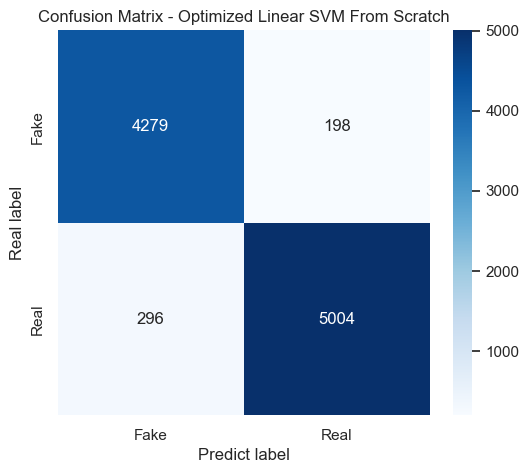

In [71]:
svm_scratch_accuracy = accuracy_score(y_test, y_pred_svm_scratch)

# Metric mặc định của sklearn lấy pos_label=1, tức là Real.
# Với bài toán Fake News Detection, cần in riêng lớp Fake.
svm_scratch_fake_precision = precision_score(
    y_test, y_pred_svm_scratch, pos_label=0, zero_division=0
)
svm_scratch_fake_recall = recall_score(
    y_test, y_pred_svm_scratch, pos_label=0, zero_division=0
)
svm_scratch_fake_f1 = f1_score(
    y_test, y_pred_svm_scratch, pos_label=0, zero_division=0
)

svm_scratch_real_precision = precision_score(
    y_test, y_pred_svm_scratch, pos_label=1, zero_division=0
)
svm_scratch_real_recall = recall_score(
    y_test, y_pred_svm_scratch, pos_label=1, zero_division=0
)
svm_scratch_real_f1 = f1_score(
    y_test, y_pred_svm_scratch, pos_label=1, zero_division=0
)

svm_scratch_macro_f1 = f1_score(
    y_test, y_pred_svm_scratch, average="macro", zero_division=0
)

print("Accuracy:", svm_scratch_accuracy)

print("\nFake News metrics:")
print("Fake Precision:", svm_scratch_fake_precision)
print("Fake Recall:", svm_scratch_fake_recall)
print("Fake F1-score:", svm_scratch_fake_f1)

print("\nReal News metrics:")
print("Real Precision:", svm_scratch_real_precision)
print("Real Recall:", svm_scratch_real_recall)
print("Real F1-score:", svm_scratch_real_f1)

print("\nMacro F1-score:", svm_scratch_macro_f1)

cm_svm_scratch = confusion_matrix(y_test, y_pred_svm_scratch)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_svm_scratch,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - Optimized Linear SVM From Scratch")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()


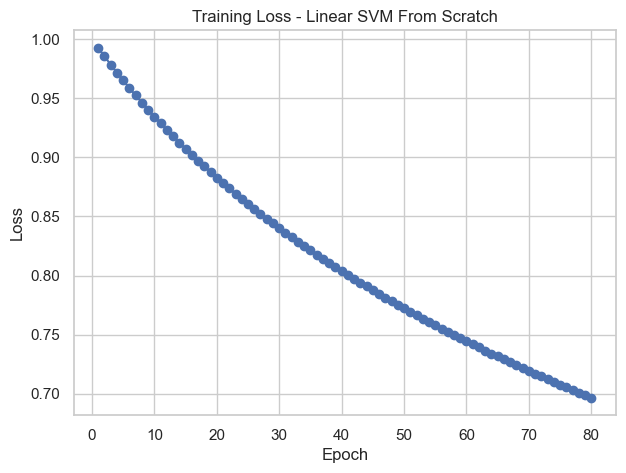

In [72]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(svm_scratch.loss_history) + 1), svm_scratch.loss_history, marker='o')
plt.title("Training Loss - Linear SVM From Scratch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# SVM Linear Algorithm


SVM Linear

In [73]:
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features= 20000,
        ngram_range= (1, 2),
        min_df=2, 
        max_df=0.95,
        sublinear_tf= True
    )),
    ('svm', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
svm_pipeline.fit(x_train, y_train)

y_pred_svm = svm_pipeline.predict(x_test)

print("Result of SVM Linear:")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=['Fake', 'Real'],
    zero_division= 0,
    digits= 6
))

Result of SVM Linear:
              precision    recall  f1-score   support

        Fake   0.997985  0.995533  0.996757      4477
        Real   0.996234  0.998302  0.997267      5300

    accuracy                       0.997034      9777
   macro avg   0.997110  0.996917  0.997012      9777
weighted avg   0.997036  0.997034  0.997034      9777



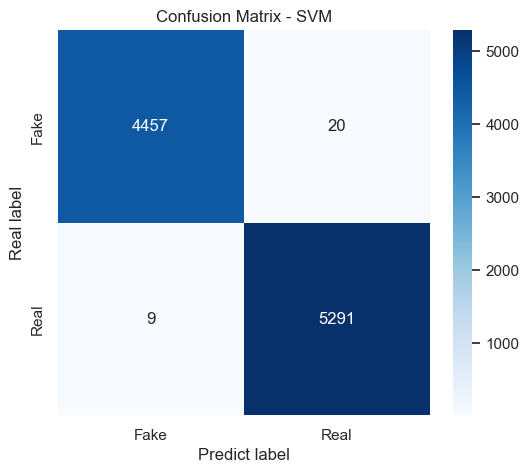

In [74]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

# Tối ưu hóa mô hình SVM với GridSearchCV

In [75]:
param_grid = {
    "tfidf__max_features": [5000, 10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
    "svm__C": [0.1, 1, 10]
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

print("Tham số tốt nhất:")
print(grid_search.best_params_)

print("\nF1-score trung bình tốt nhất trên cross-validation:")
print(grid_search.best_score_)

best_svm_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Tham số tốt nhất:
{'svm__C': 1, 'tfidf__max_features': 10000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

F1-score trung bình tốt nhất trên cross-validation:
0.9968583940757156


Evaluate model after optimazing

In [76]:
y_pred_best_svm = best_svm_model.predict(x_test)

svm_accuracy = accuracy_score(y_test, y_pred_best_svm)
svm_precision = precision_score(y_test, y_pred_best_svm, zero_division=0)
svm_recall = recall_score(y_test, y_pred_best_svm, zero_division=0)
svm_f1 = f1_score(y_test, y_pred_best_svm, zero_division=0)

print("Accuracy:", svm_accuracy)
print("Precision:", svm_precision)
print("Recall:", svm_recall)
print("F1-score:", svm_f1)

print("\nResult:")
print(classification_report(
    y_test,
    y_pred_best_svm,
    target_names=["Fake", "Real"],
    zero_division=0,
    digits=6
))

Accuracy: 0.9970338549657359
Precision: 0.9960474308300395
Recall: 0.9984905660377359
F1-score: 0.9972675021200414

Result:
              precision    recall  f1-score   support

        Fake   0.998208  0.995309  0.996757      4477
        Real   0.996047  0.998491  0.997268      5300

    accuracy                       0.997034      9777
   macro avg   0.997128  0.996900  0.997012      9777
weighted avg   0.997037  0.997034  0.997034      9777



# Multinomial Naive Bayes

In [77]:
naive_bayes_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('nb', MultinomialNB(alpha=0.1)) 
])

naive_bayes_pipeline.fit(x_train, y_train)

y_pred_naive_bayes = naive_bayes_pipeline.predict(x_test)

print("Result of Logistic Regression:")
print(classification_report(
    y_test,
    y_pred_naive_bayes,
    target_names=['Fake', 'Real'],
    zero_division=0,
    digits=6
))

Result of Logistic Regression:
              precision    recall  f1-score   support

        Fake   0.959768  0.959124  0.959446      4477
        Real   0.965491  0.966038  0.965764      5300

    accuracy                       0.962872      9777
   macro avg   0.962629  0.962581  0.962605      9777
weighted avg   0.962870  0.962872  0.962871      9777



Accuracy: 0.9628720466400736
Precision: 0.965491231378465
Recall: 0.9660377358490566
F1-score: 0.9657644063001037


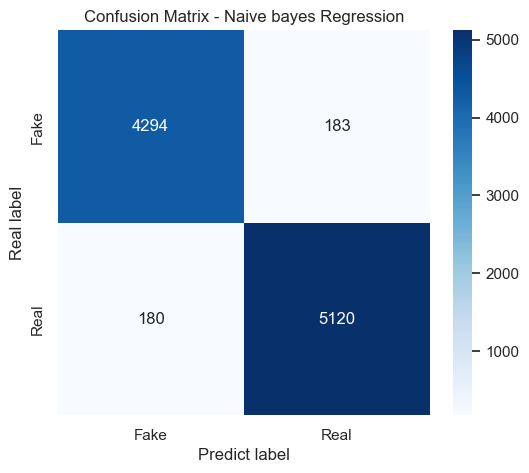

In [78]:
bayes_accuracy = accuracy_score(y_test, y_pred_naive_bayes)
bayes_precision = precision_score(y_test, y_pred_naive_bayes, zero_division=0)
bayes_recall = recall_score(y_test, y_pred_naive_bayes, zero_division=0)
bayes_f1 = f1_score(y_test, y_pred_naive_bayes, zero_division=0)

print("Accuracy:", bayes_accuracy)
print("Precision:", bayes_precision)
print("Recall:", bayes_recall)
print("F1-score:", bayes_f1)

cm_bayes = confusion_matrix(y_test, y_pred_naive_bayes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bayes,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - Naive bayes Regression")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

# Logistic Regression

In [79]:
logistic_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('logistic', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        solver='liblinear',
        random_state=RANDOM_STATE
    ))
])

logistic_pipeline.fit(x_train, y_train)

y_pred_logistic = logistic_pipeline.predict(x_test)

print("Result of Logistic Regression:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=['Fake', 'Real'],
    zero_division=0,
    digits=6
))

Result of Logistic Regression:
              precision    recall  f1-score   support

        Fake   0.995494  0.987045  0.991252      4477
        Real   0.989135  0.996226  0.992668      5300

    accuracy                       0.992022      9777
   macro avg   0.992314  0.991636  0.991960      9777
weighted avg   0.992047  0.992022  0.992019      9777



Accuracy: 0.9920220926664621
Precision: 0.9891345073061072
Recall: 0.9962264150943396
F1-score: 0.9926677946982515


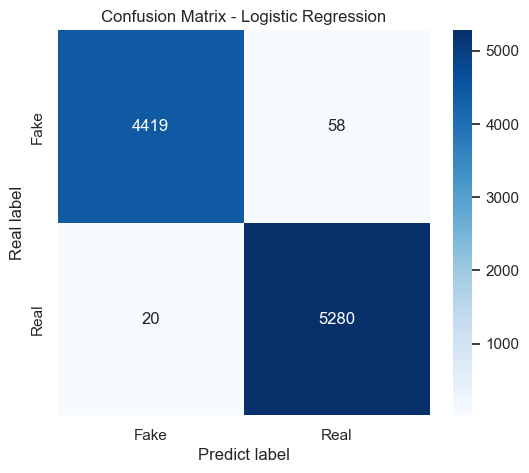

In [80]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic, zero_division=0)
logistic_recall = recall_score(y_test, y_pred_logistic, zero_division=0)
logistic_f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-score:", logistic_f1)

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predict label")
plt.ylabel("Real label")
plt.show()

# So sánh kết quả mô hình

In [81]:
def collect_binary_metrics(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Fake Precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fake Recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fake F1-score": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Real Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Real Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Real F1-score": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Macro F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

comparison_results = pd.DataFrame([
    collect_binary_metrics("Multinomial Naive Bayes", y_test, y_pred_naive_bayes),
    collect_binary_metrics("Logistic Regression", y_test, y_pred_logistic),
    collect_binary_metrics("Linear SVM (library)", y_test, y_pred_best_svm),
    collect_binary_metrics("Linear SVM (from scratch optimized)", y_test, y_pred_svm_scratch)
])

comparison_results


,Model,Accuracy,Fake Precision,Fake Recall,Fake F1-score,Real Precision,Real Recall,Real F1-score,Macro F1-score
0,Multinomial Naive Bayes,0.962872,0.959768,0.959124,0.959446,0.965491,0.966038,0.965764,0.962605
1,Logistic Regression,0.992022,0.995494,0.987045,0.991252,0.989135,0.996226,0.992668,0.991960
2,Linear SVM (library),0.997034,0.998208,0.995309,0.996757,0.996047,0.998491,0.997268,0.997012
3,Linear SVM (from scratch optimized),0.949473,0.935301,0.955774,0.945426,0.961938,0.944151,0.952961,0.949194


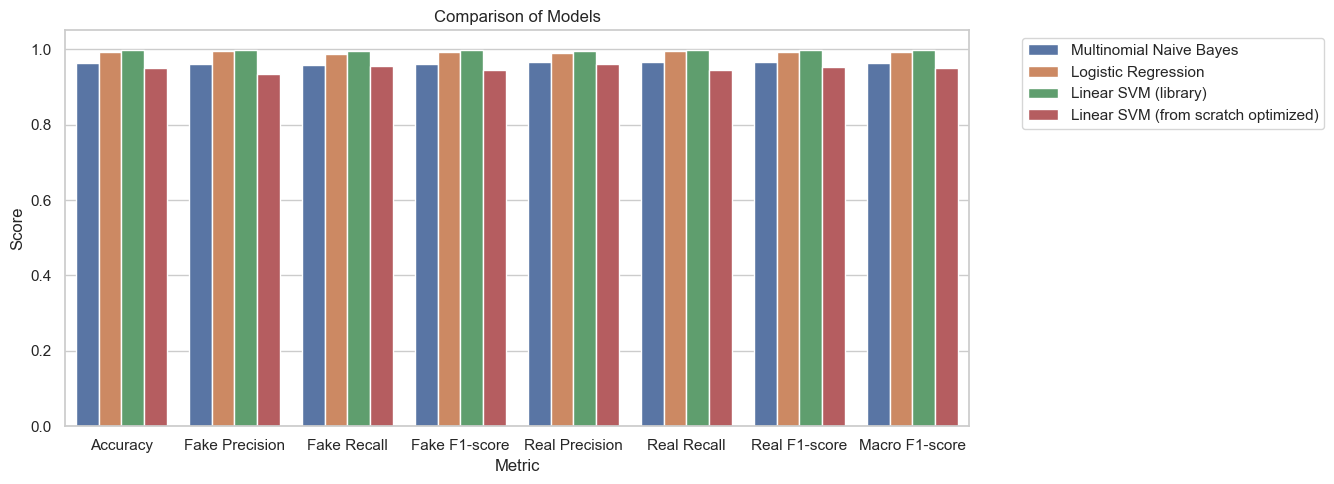

In [82]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=comparison_results.melt(id_vars="Model", var_name="Metric", value_name="Score"),
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Comparison of Models")
plt.tight_layout()
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [83]:
# Lưu model SVM tốt nhất, gồm cả TF-IDF + LinearSVC
joblib.dump(best_svm_model, "svm_pipeline_model_1.jb")

print("Đã lưu model vào:svm_pipeline_model_1.jb")

Đã lưu model vào:svm_pipeline_model_1.jb


# MA TRẬN TỪ/NGỮ LÀM TĂNG TỶ LỆ MÔ HÌNH DỰ ĐOÁN SAI

In [ ]:
# ============================================================
# MA TRẬN TỪ/NGỮ LÀM TĂNG TỶ LỆ MÔ HÌNH DỰ ĐOÁN SAI
# ============================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


def extract_tfidf_and_classifier(pipeline_model):
    """Lấy TF-IDF vectorizer và classifier từ Pipeline."""
    tfidf = None
    clf = None

    for name, step in pipeline_model.named_steps.items():
        if hasattr(step, "get_feature_names_out") and hasattr(step, "transform"):
            tfidf = step

    clf = pipeline_model.steps[-1][1]
    return tfidf, clf


def build_word_error_matrix(
    pipeline_model,
    x_text,
    y_true,
    y_pred,
    min_docs=30,
    top_n=30
):
    """
    Tạo ma trận các từ/cụm từ có liên quan đến lỗi dự đoán.

    Quy ước nhãn:
    - 0 = Fake
    - 1 = Real

    Các cột quan trọng:
    - error_rate_with_term: tỷ lệ sai trong các văn bản có chứa từ/cụm từ đó
    - error_rate_without_term: tỷ lệ sai trong các văn bản không chứa từ/cụm từ đó
    - error_lift: mức tăng lỗi. Nếu > 1, văn bản chứa từ đó có tỷ lệ sai cao hơn trung bình nhóm không chứa từ đó
    - fake_as_real_rate: tỷ lệ lỗi Fake bị đoán thành Real trong các văn bản có chứa từ đó
    - real_as_fake_rate: tỷ lệ lỗi Real bị đoán thành Fake trong các văn bản có chứa từ đó
    """

    tfidf, clf = extract_tfidf_and_classifier(pipeline_model)

    if tfidf is None:
        raise ValueError("Không tìm thấy TfidfVectorizer trong pipeline_model.")

    X_tfidf = tfidf.transform(x_text)

    # Chỉ quan tâm văn bản có chứa từ hay không, không cần trọng số TF-IDF ở bước thống kê lỗi
    X_bin = X_tfidf.astype(bool).astype(np.int8)

    feature_names = np.array(tfidf.get_feature_names_out())

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    error_mask = (y_true != y_pred).astype(int)
    fake_as_real_mask = ((y_true == 0) & (y_pred == 1)).astype(int)
    real_as_fake_mask = ((y_true == 1) & (y_pred == 0)).astype(int)

    n_total = X_bin.shape[0]

    n_with = np.asarray(X_bin.sum(axis=0)).ravel()
    n_without = n_total - n_with

    error_count = np.asarray(X_bin.T @ error_mask).ravel()
    fake_as_real_count = np.asarray(X_bin.T @ fake_as_real_mask).ravel()
    real_as_fake_count = np.asarray(X_bin.T @ real_as_fake_mask).ravel()

    total_error = error_mask.sum()
    error_without = total_error - error_count

    error_rate_with = np.divide(
        error_count,
        n_with,
        out=np.zeros_like(error_count, dtype=float),
        where=n_with != 0
    )

    error_rate_without = np.divide(
        error_without,
        n_without,
        out=np.zeros_like(error_without, dtype=float),
        where=n_without != 0
    )

    error_lift = np.divide(
        error_rate_with,
        error_rate_without,
        out=np.zeros_like(error_rate_with, dtype=float),
        where=error_rate_without != 0
    )

    fake_as_real_rate = np.divide(
        fake_as_real_count,
        n_with,
        out=np.zeros_like(fake_as_real_count, dtype=float),
        where=n_with != 0
    )

    real_as_fake_rate = np.divide(
        real_as_fake_count,
        n_with,
        out=np.zeros_like(real_as_fake_count, dtype=float),
        where=n_with != 0
    )

    # Nếu classifier tuyến tính có coef_, thêm hướng nghiêng của mô hình
    coef = np.full(len(feature_names), np.nan)
    model_leans_to = np.array(["Unknown"] * len(feature_names), dtype=object)

    if hasattr(clf, "coef_"):
        coef = clf.coef_[0]
        model_leans_to = np.where(coef >= 0, "Real", "Fake")

    matrix_df = pd.DataFrame({
        "term": feature_names,
        "n_docs_with_term": n_with,
        "error_count": error_count,
        "error_rate_with_term": error_rate_with,
        "error_rate_without_term": error_rate_without,
        "error_lift": error_lift,
        "fake_as_real_count": fake_as_real_count,
        "fake_as_real_rate": fake_as_real_rate,
        "real_as_fake_count": real_as_fake_count,
        "real_as_fake_rate": real_as_fake_rate,
        "model_coef": coef,
        "model_leans_to": model_leans_to
    })

    # Bỏ các từ quá hiếm để tránh kết luận nhiễu
    matrix_df = matrix_df[matrix_df["n_docs_with_term"] >= min_docs].copy()

    # Các từ/ngữ làm tỷ lệ sai tăng mạnh nhất
    risky_terms = matrix_df.sort_values(
        by=["error_lift", "error_rate_with_term", "error_count"],
        ascending=False
    ).head(top_n)

    # Các từ/ngữ thường xuất hiện trong lỗi Fake bị đoán thành Real
    fake_as_real_terms = matrix_df.sort_values(
        by=["fake_as_real_rate", "fake_as_real_count", "error_lift"],
        ascending=False
    ).head(top_n)

    # Các từ/ngữ thường xuất hiện trong lỗi Real bị đoán thành Fake
    real_as_fake_terms = matrix_df.sort_values(
        by=["real_as_fake_rate", "real_as_fake_count", "error_lift"],
        ascending=False
    ).head(top_n)

    return matrix_df, risky_terms, fake_as_real_terms, real_as_fake_terms


word_error_matrix, risky_terms, fake_as_real_terms, real_as_fake_terms = build_word_error_matrix(
    pipeline_model=best_svm_model,
    x_text=x_test,
    y_true=y_test,
    y_pred=y_pred_best_svm,
    min_docs=30,
    top_n=30
)

print("Tổng số từ/cụm từ được xét sau khi lọc min_docs:", len(word_error_matrix))
print("\nGiải thích nhanh:")
print("- error_lift > 1: có từ/cụm từ này thì tỷ lệ dự đoán sai cao hơn nhóm không có từ/cụm từ đó")
print("- fake_as_real_rate cao: Fake dễ bị mô hình đoán nhầm thành Real")
print("- real_as_fake_rate cao: Real dễ bị mô hình đoán nhầm thành Fake")

print("\n1) Ma trận TOP từ/cụm từ làm tăng tỷ lệ dự đoán sai chung:")
display(risky_terms[[
    "term",
    "n_docs_with_term",
    "error_count",
    "error_rate_with_term",
    "error_rate_without_term",
    "error_lift",
    "fake_as_real_rate",
    "real_as_fake_rate",
    "model_coef",
    "model_leans_to"
]])

print("\n2) Ma trận TOP từ/cụm từ liên quan đến lỗi Fake bị đoán thành Real:")
display(fake_as_real_terms[[
    "term",
    "n_docs_with_term",
    "fake_as_real_count",
    "fake_as_real_rate",
    "error_lift",
    "model_coef",
    "model_leans_to"
]])

print("\n3) Ma trận TOP từ/cụm từ liên quan đến lỗi Real bị đoán thành Fake:")
display(real_as_fake_terms[[
    "term",
    "n_docs_with_term",
    "real_as_fake_count",
    "real_as_fake_rate",
    "error_lift",
    "model_coef",
    "model_leans_to"
]])



Tổng số từ/cụm từ được xét sau khi lọc min_docs: 8684

Giải thích nhanh:
- error_lift > 1: có từ/cụm từ này thì tỷ lệ dự đoán sai cao hơn nhóm không có từ/cụm từ đó
- fake_as_real_rate cao: Fake dễ bị mô hình đoán nhầm thành Real
- real_as_fake_rate cao: Real dễ bị mô hình đoán nhầm thành Fake

1) Ma trận TOP từ/cụm từ làm tăng tỷ lệ dự đoán sai chung:


,term,n_docs_with_term,error_count,error_rate_with_term,error_rate_without_term,error_lift,fake_as_real_rate,real_as_fake_rate,model_coef,model_leans_to
8169,specify,35,3,0.085714,0.002669,32.116484,0.057143,0.028571,0.018670,Real
205,agricultural,36,3,0.083333,0.002669,31.221154,0.083333,0.000000,0.360232,Real
567,assure,38,3,0.078947,0.002670,29.571862,0.052632,0.026316,-0.000631,Fake
4057,importantly,44,3,0.068182,0.002671,25.523601,0.022727,0.045455,-0.335792,Fake
1058,buildup,30,2,0.066667,0.002770,24.066667,0.066667,0.000000,-0.022171,Fake
4902,longrange,31,2,0.064516,0.002770,23.287933,0.064516,0.000000,-0.100672,Fake
9663,week republican,31,2,0.064516,0.002770,23.287933,0.064516,0.000000,0.056497,Real
6342,political campaign,32,2,0.062500,0.002771,22.557870,0.062500,0.000000,0.037546,Real
5304,ministry spokeswoman,33,2,0.060606,0.002771,21.872054,0.060606,0.000000,0.028540,Real
967,boundary,34,2,0.058824,0.002771,21.226580,0.000000,0.058824,0.224392,Real



2) Ma trận TOP từ/cụm từ liên quan đến lỗi Fake bị đoán thành Real:


,term,n_docs_with_term,fake_as_real_count,fake_as_real_rate,error_lift,model_coef,model_leans_to
205,agricultural,36,3,0.083333,31.221154,0.360232,Real
1058,buildup,30,2,0.066667,24.066667,-0.022171,Fake
4902,longrange,31,2,0.064516,23.287933,-0.100672,Fake
9663,week republican,31,2,0.064516,23.287933,0.056497,Real
6342,political campaign,32,2,0.062500,22.557870,0.037546,Real
5304,ministry spokeswoman,33,2,0.060606,21.872054,0.028540,Real
1815,cotton,34,2,0.058824,21.226580,-0.283345,Fake
8169,specify,35,2,0.057143,32.116484,0.018670,Real
6226,petroleum,36,2,0.055556,20.043210,-0.096358,Fake
4088,inclusion,37,2,0.054054,19.499499,-0.100607,Fake



3) Ma trận TOP từ/cụm từ liên quan đến lỗi Real bị đoán thành Fake:


,term,n_docs_with_term,real_as_fake_count,real_as_fake_rate,error_lift,model_coef,model_leans_to
967,boundary,34,2,0.058824,21.226580,0.224392,Real
6243,photographer,42,2,0.047619,17.169312,0.053470,Real
1831,could see,43,2,0.046512,16.768303,-0.022670,Fake
2490,drink,43,2,0.046512,16.768303,0.174261,Real
4057,importantly,44,2,0.045455,25.523601,-0.335792,Fake
3131,find way,67,3,0.044776,16.722158,0.016307,Real
810,best interest,45,2,0.044444,16.019753,0.069400,Real
3622,group people,51,2,0.039216,14.126362,-0.104137,Fake
5421,mount,52,2,0.038462,13.853276,0.076959,Real
9943,year president,52,2,0.038462,13.853276,-0.198817,Fake


## Print wordcloud 

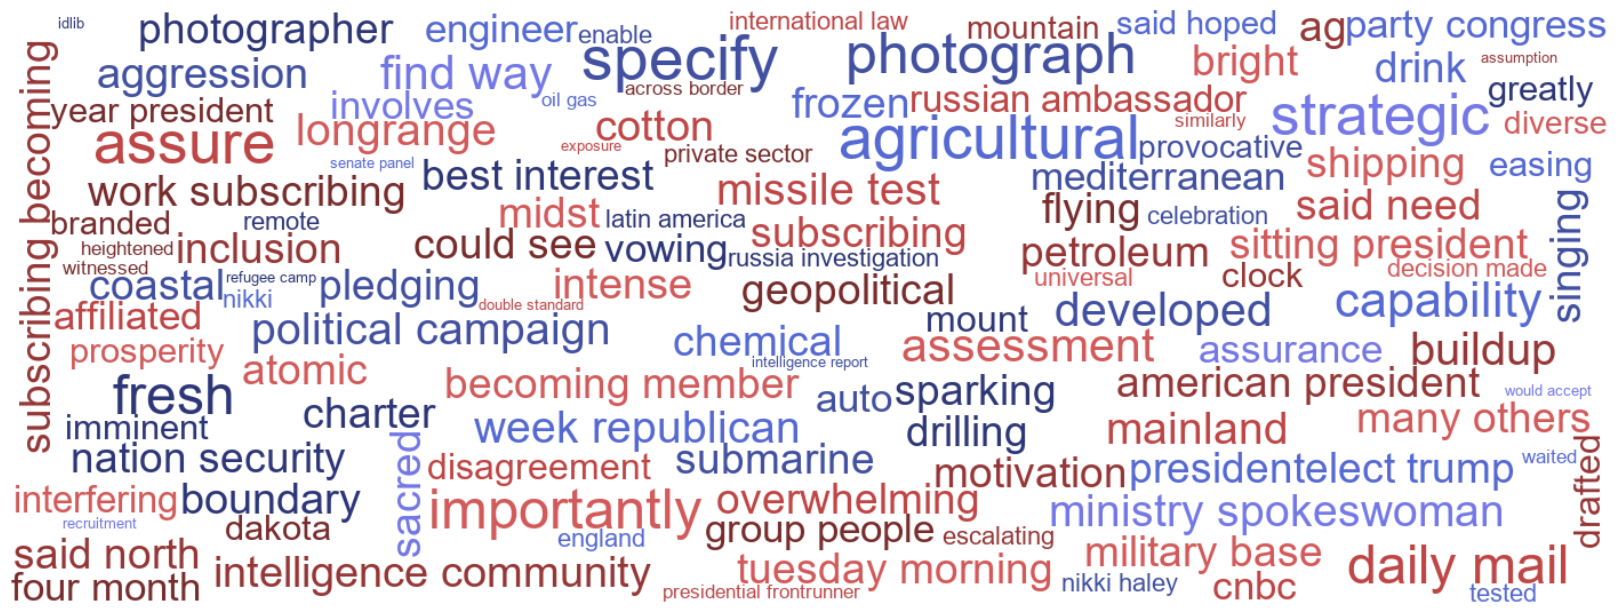

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import random
import os

# ============================================================
# 1. CHỌN BẢNG TỪ/CỤM TỪ ĐỂ VẼ
# ============================================================
# Có thể đổi risky_terms thành:
# - fake_as_real_terms
# - real_as_fake_terms
# - word_error_matrix

df_wordcloud = risky_terms.copy()

# Nếu muốn vẽ nhiều từ hơn:
df_wordcloud = word_error_matrix.sort_values("error_lift", ascending=False).head(120).copy()


# ============================================================
# 2. TẠO TRỌNG SỐ CHO TỪ
# ============================================================
# Có nhiều cách chọn trọng số:
# Cách 1: từ nào error_lift cao thì chữ to hơn
df_wordcloud["weight"] = df_wordcloud["error_lift"] * df_wordcloud["error_count"]

# Cách 2: nếu muốn từ xuất hiện nhiều thì chữ to hơn, dùng dòng này thay cho dòng trên
# df_wordcloud["weight"] = df_wordcloud["n_docs_with_term"]

# Cách 3: nếu muốn tập trung lỗi Fake -> Real
# df_wordcloud["weight"] = df_wordcloud["fake_as_real_count"]

# Cách 4: nếu muốn tập trung lỗi Real -> Fake
# df_wordcloud["weight"] = df_wordcloud["real_as_fake_count"]


# Loại bỏ giá trị lỗi hoặc bằng 0
df_wordcloud = df_wordcloud.replace([np.inf, -np.inf], np.nan)
df_wordcloud = df_wordcloud.dropna(subset=["term", "weight"])
df_wordcloud = df_wordcloud[df_wordcloud["weight"] > 0]


# Chuyển thành dictionary: {"từ/cụm từ": trọng số}
word_freq = dict(zip(df_wordcloud["term"], df_wordcloud["weight"]))


# ============================================================
# 3. CHỌN FONT HỖ TRỢ TIẾNG VIỆT
# ============================================================
# Windows thường dùng được Arial
font_path = "C:/Windows/Fonts/arial.ttf"

# Nếu lỗi font, thử các font khác:
# font_path = "C:/Windows/Fonts/times.ttf"
# font_path = "C:/Windows/Fonts/calibri.ttf"

if not os.path.exists(font_path):
    font_path = None
    print("Không tìm thấy font Windows, WordCloud sẽ dùng font mặc định.")


# ============================================================
# 4. HÀM TÔ MÀU ĐỎ - XANH GIỐNG HÌNH MẪU
# ============================================================
def red_blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    """
    Tạo màu đỏ/xanh ngẫu nhiên giống ảnh mẫu.
    Từ nào mô hình nghiêng về Real thì thiên xanh.
    Từ nào mô hình nghiêng về Fake thì thiên đỏ.
    """

    if "model_leans_to" in df_wordcloud.columns:
        row = df_wordcloud[df_wordcloud["term"] == word]

        if len(row) > 0:
            lean = row.iloc[0]["model_leans_to"]

            if lean == "Real":
                # Xanh tím
                colors = [
                    "rgb(65, 80, 160)",
                    "rgb(85, 105, 210)",
                    "rgb(115, 120, 230)",
                    "rgb(45, 55, 120)"
                ]
            elif lean == "Fake":
                # Đỏ nâu
                colors = [
                    "rgb(150, 55, 55)",
                    "rgb(190, 70, 70)",
                    "rgb(210, 90, 90)",
                    "rgb(120, 45, 45)"
                ]
            else:
                colors = [
                    "rgb(90, 90, 160)",
                    "rgb(180, 70, 70)"
                ]

            return random.choice(colors)

    # Nếu không có cột model_leans_to thì random đỏ/xanh
    return random.choice([
        "rgb(65, 80, 160)",
        "rgb(85, 105, 210)",
        "rgb(115, 120, 230)",
        "rgb(150, 55, 55)",
        "rgb(190, 70, 70)",
        "rgb(210, 90, 90)"
    ])


# ============================================================
# 5. VẼ WORD CLOUD
# ============================================================
wc = WordCloud(
    width=1400,
    height=520,
    background_color="white",
    font_path=font_path,
    max_words=150,
    prefer_horizontal=0.95,
    relative_scaling=0.45,
    min_font_size=8,
    max_font_size=55,
    margin=2,
    random_state=42,
    collocations=False
).generate_from_frequencies(word_freq)

wc = wc.recolor(color_func=red_blue_color_func, random_state=42)

plt.figure(figsize=(16, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


# ============================================================
# 6. LƯU ẢNH
# ============================================================
wc.to_file("wordcloud_error_terms.png")

# Phân tích các mẫu dự đoán sai

In [ ]:
import re
import numpy as np
import pandas as pd
from IPython.display import display, HTML


# =========================
# 1. Tạo DataFrame chứa các mẫu dự đoán sai
# =========================

error_df = pd.DataFrame({
    "text": x_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "pred_label": pd.Series(y_pred_best_svm).reset_index(drop=True)
})

# Chỉ lấy những mẫu mô hình dự đoán sai
error_df = error_df[error_df["true_label"] != error_df["pred_label"]].copy()

label_name = {
    0: "Fake News",
    1: "Real News"
}
print("0 = Fake News " \
"      1 = Real News")
print("\nTổng số mẫu dự đoán sai:", len(error_df))
print("\n5 mẫu đầu tiên trong", len(error_df),"mẫu sai là: ")
display(error_df.head())


# =========================
# 2. Hàm lấy từ/cụm từ làm mô hình nghiêng về nhãn đã dự đoán
# =========================

def get_vectorizer_and_classifier(pipeline_model):
    """
    Lấy TF-IDF vectorizer và classifier cuối cùng từ Pipeline.
    Dùng được cho Pipeline dạng:
    Pipeline([
        ('tfidf', TfidfVectorizer(...)),
        ('svm', LinearSVC(...))
    ])
    """

    tfidf = None

    for name, step in pipeline_model.named_steps.items():
        if hasattr(step, "get_feature_names_out") and hasattr(step, "transform"):
            tfidf = step
            break

    classifier = pipeline_model.steps[-1][1]

    return tfidf, classifier


def get_words_supporting_prediction(pipeline_model, text, predicted_label, top_n=8):
    """
    Lấy các từ/cụm từ trong văn bản làm mô hình nghiêng về nhãn predicted_label.

    Quy ước:
    0 = Fake News
    1 = Real News

    Với LinearSVC:
    - contribution dương thường nghiêng về class 1
    - contribution âm thường nghiêng về class 0
    """

    tfidf, classifier = get_vectorizer_and_classifier(pipeline_model)

    if tfidf is None or classifier is None:
        return []

    if not hasattr(classifier, "coef_"):
        return []

    X = tfidf.transform([text])
    feature_names = tfidf.get_feature_names_out()
    coef = classifier.coef_[0]

    contributions = X.multiply(coef).toarray().ravel()
    nonzero_indices = X.nonzero()[1]

    classes = list(classifier.classes_)

    # Nếu mô hình dự đoán Real
    if predicted_label == classes[1]:
        candidates = [
            (feature_names[i], contributions[i])
            for i in nonzero_indices
            if contributions[i] > 0
        ]

    # Nếu mô hình dự đoán Fake
    else:
        candidates = [
            (feature_names[i], abs(contributions[i]))
            for i in nonzero_indices
            if contributions[i] < 0
        ]

    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)

    return candidates[:top_n]


# =========================
# 3. Hàm phân tích nguyên nhân dự đoán sai
# =========================

# =========================
# TỰ ĐỘNG LẤY TỪ NGHIÊNG VỀ FAKE / REAL TỪ MODEL
# =========================

def extract_model_keywords(pipeline_model, top_n=30):
    """
    Tự động lấy các từ/cụm từ quan trọng nhất từ mô hình Linear SVM hoặc Logistic Regression.

    Quy ước:
    0 = Fake News
    1 = Real News

    Với mô hình nhị phân:
    - coef âm mạnh  -> nghiêng về class 0, tức Fake
    - coef dương mạnh -> nghiêng về class 1, tức Real
    """

    tfidf, classifier = get_vectorizer_and_classifier(pipeline_model)

    if tfidf is None or classifier is None:
        return set(), set()

    if not hasattr(classifier, "coef_"):
        return set(), set()

    feature_names = tfidf.get_feature_names_out()
    coef = classifier.coef_[0]

    # Lấy chỉ số các trọng số nhỏ nhất: nghiêng về Fake
    fake_indices = np.argsort(coef)[:top_n]

    # Lấy chỉ số các trọng số lớn nhất: nghiêng về Real
    real_indices = np.argsort(coef)[-top_n:]

    fake_keywords = set(feature_names[fake_indices])
    real_keywords = set(feature_names[real_indices])

    return fake_keywords, real_keywords


fake_style_words, real_style_words = extract_model_keywords(
    best_svm_model,
    top_n=40
)

print("Các từ/cụm từ mô hình học là nghiêng về Fake:")
print(fake_style_words)

print("\nCác từ/cụm từ mô hình học là nghiêng về Real:")
print(real_style_words)


def count_exclamation(text):
    return text.count("!")


def count_uppercase_words(text):
    words = re.findall(r"\b[A-Z]{2,}\b", str(text))
    return len(words)


def word_count(text):
    return len(str(text).split())


def count_keyword_overlap(text, keyword_set):
    text_lower = str(text).lower()
    tokens = set(re.findall(r"\b[a-zA-Z]+\b", text_lower))
    return len(tokens.intersection(keyword_set))


def analyze_wrong_prediction_reason(text, true_label, pred_label):
    """
    Sinh ra các nhận xét giải thích vì sao mô hình có thể dự đoán sai.
    Đây là phân tích dựa trên từ khóa mà chính mô hình học được từ dữ liệu.
    """

    reasons = []

    n_words = word_count(text)
    n_exclamation = count_exclamation(text)
    n_uppercase = count_uppercase_words(text)
    fake_word_count = count_keyword_overlap(text, fake_style_words)
    real_word_count = count_keyword_overlap(text, real_style_words)

    # Trường hợp 1:
    # Tin thật nhưng bị dự đoán là giả
    if true_label == 1 and pred_label == 0:
        if fake_word_count > 0:
            reasons.append(
                f"Có {fake_word_count} từ/cụm từ mà mô hình đã học là nghiêng về Fake News."
            )

        if n_exclamation > 0:
            reasons.append(
                f"Có {n_exclamation} dấu chấm than, làm văn bản có vẻ giật gân/cảm xúc."
            )

        if n_uppercase > 3:
            reasons.append(
                f"Có {n_uppercase} từ viết hoa, dễ tạo cảm giác tiêu đề quá cảm xúc."
            )

        if n_words < 80:
            reasons.append(
                f"Nội dung khá ngắn ({n_words} từ), khiến mô hình thiếu ngữ cảnh để phân biệt tin thật."
            )

        if not reasons:
            reasons.append(
                "Tin thật nhưng chứa đặc trưng từ vựng khiến mô hình nghiêng về Fake News."
            )

    # Trường hợp 2:
    # Tin giả nhưng bị dự đoán là thật
    elif true_label == 0 and pred_label == 1:
        if real_word_count > 0:
            reasons.append(
                f"Có {real_word_count} từ/cụm từ mà mô hình đã học là nghiêng về Real News."
            )

        if n_words >= 120:
            reasons.append(
                f"Nội dung tương đối dài ({n_words} từ), cấu trúc giống một bài báo thật."
            )

        if real_word_count >= fake_word_count:
            reasons.append(
                "Văn bản có nhiều dấu hiệu từ vựng nghiêng về Real hơn Fake."
            )

        if not reasons:
            reasons.append(
                "Tin giả nhưng chứa đặc trưng từ vựng khiến mô hình nghiêng về Real News."
            )

    return reasons


# =========================
# 4. Chọn 5-10 mẫu dự đoán sai để phân tích
# =========================

# Lấy tối đa 5 mẫu: Tin thật nhưng bị dự đoán là giả
real_pred_fake = error_df[
    (error_df["true_label"] == 1) &
    (error_df["pred_label"] == 0)
].head(5)

# Lấy tối đa 5 mẫu: Tin giả nhưng bị dự đoán là thật
fake_pred_real = error_df[
    (error_df["true_label"] == 0) &
    (error_df["pred_label"] == 1)
].head(5)

selected_errors = pd.concat([real_pred_fake, fake_pred_real], axis=0)

print("\nSố mẫu được chọn để phân tích:", len(selected_errors))
display(selected_errors)


# =========================
# 5. In phân tích chi tiết từng mẫu
# =========================

def shorten_text(text, max_len=700):
    text = str(text).replace("\n", " ").strip()
    text = re.sub(r"\s+", " ", text)

    if len(text) > max_len:
        return text[:max_len] + "..."

    return text


html_output = ""

for idx, row in selected_errors.iterrows():
    text = row["text"]
    true_label = row["true_label"]
    pred_label = row["pred_label"]

    important_words = get_words_supporting_prediction(
        best_svm_model,
        text,
        predicted_label=pred_label,
        top_n=8
    )

    reasons = analyze_wrong_prediction_reason(
        text,
        true_label=true_label,
        pred_label=pred_label
    )

    html_output += f"""
    <div style="
        border: 1px solid #ddd;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 18px;
        background-color: #121212;
        color: #ffffff;
    ">
        <h3 style="color: #ffffff;">Mẫu dự đoán sai #{idx}</h3>

        <p><b>Nhãn thật:</b> {label_name[true_label]}</p>
        <p><b>Mô hình dự đoán:</b> {label_name[pred_label]}</p>

        <p><b>Nội dung rút gọn:</b></p>
        <p style="background-color: #2a2a2a; padding: 10px; border-radius: 6px;">
            {shorten_text(text)}
        </p>

        <p><b>Từ/cụm từ làm mô hình nghiêng về {label_name[pred_label]}:</b></p>
        <ul>
    """

    if important_words:
        for word, score in important_words:
            html_output += f"<li>{word}</li>"
    else:
        html_output += "<li>Không tìm thấy từ/cụm từ nổi bật.</li>"

    html_output += """
        </ul>

        <p><b>Nguyên nhân có thể gây nhầm lẫn:</b></p>
        <ul>
    """

    for reason in reasons:
        html_output += f"<li>{reason}</li>"

    html_output += """
        </ul>
    </div>
    """

display(HTML(html_output))


0 = Fake News       1 = Real News

Tổng số mẫu dự đoán sai: 29

5 mẫu đầu tiên trong 29 mẫu sai là: 


,text,true_label,pred_label
155,text trump recognizes jerusalem israel capital...,1,0
197,michelle sasha malia join barack trip communis...,0,1
316,ford new ceo snub president trumpwill build fo...,0,1
748,donald trump effigy burned across mexico easte...,0,1
819,syria nikki haley threatens despite internatio...,0,1


Các từ/cụm từ mô hình học là nghiêng về Fake:
{'video', 'obama', 'report', 'mail', 'american', 'via', 'century wire', 'saidthe', 'huge', 'president obama', 'bloomberg', 'mr', 'liberal', 'news', 'rep', 'wfb', 'president trump', 'ap', 'wow', 'reportedly', 'image via', 'entire story', 'gov', 'sen', 'gop', 'read', 'even', 'wire', 'america', 'breaking', 'isi', 'image', 'watch', 'terror', 'nyp', 'recently', 'breitbart', 'hillary', 'entire', 'daily mail'}

Các từ/cụm từ mô hình học là nghiêng về Real:
{'york reuters', 'tuesday', 'democrat hillary', 'ive', 'reuters republican', 'washington', 'comment', 'there', 'president donald', 'dont', 'im', 'barack obamas', 'graphic', 'thats', 'said statement', 'doesnt', 'friday', 'news conference', 'britain', 'he', 'year', 'nov', 'nov election', 'washington reuters', 'thursday', 'wednesday', 'president barack', 'showed', 'rival', 'km', 'said trump', 'saying', 'london reuters', 'reuters', 'factbox', 'reuters president', 'said', 'twitter', 'monday', 'london

,text,true_label,pred_label
155,text trump recognizes jerusalem israel capital...,1,0
944,hacker play minute islamic state propaganda sw...,1,0
1506,picture story reaching rescue rohingya woman p...,1,0
1698,commentary long north korea nuke u city near f...,1,0
3788,text exfbi director comeys prepared testimony ...,1,0
197,michelle sasha malia join barack trip communis...,0,1
316,ford new ceo snub president trumpwill build fo...,0,1
748,donald trump effigy burned across mexico easte...,0,1
819,syria nikki haley threatens despite internatio...,0,1
898,u import african refugee plague spread caused ...,0,1
